#  True Colour image of Budapest from the Sentinel-2 satellite

## Sentinel Hub Process API – Python example

This notebook will demonstrate how to use **Sentinel** data from the Copernicus Hub:

- Sentinel-2 L2A data
- True Color (RGB: B04, B03, B02) composite
- Budapest, 2024. summer
- `sentinelhub-py` library

In [32]:
# 1. Sentinel Hub lib
!pip install sentinelhub --quiet

In [33]:
# 2. Sentinel Hub configuration

from sentinelhub import (
    SHConfig,
    SentinelHubRequest,
    BBox,
    CRS,
    DataCollection,
    MimeType,
    bbox_to_dimensions,
)
import matplotlib.pyplot as plt
import numpy as np


In [34]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("sentinel_client_id")
secret_value_1 = user_secrets.get_secret("sentinel_client_secret")


In [35]:
# Copernicus Data Space configuration
config = SHConfig(
    sh_client_id=secret_value_0,
    sh_client_secret=secret_value_1,
    sh_token_url="https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
    sh_base_url="https://sh.dataspace.copernicus.eu",
)
print(f"Base URL   : {config.sh_base_url}")
print(f"Token URL  : {config.sh_token_url}")
print(f"Client ID  : {config.sh_client_id[:8]}...")

Base URL   : https://sh.dataspace.copernicus.eu
Token URL  : https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token
Client ID  : sh-d9573...


In [36]:
from sentinelhub import DataCollection

# Copernicus Data Space owns DataCollection defined
# A SENTINEL2_L2A default values are from an older, deprecated server,
# redefine to the CDSE server
SENTINEL2_L2A_CDSE = DataCollection.define(
    name="SENTINEL2_L2A_CDSE",
    api_id="sentinel-2-l2a",
    catalog_id="sentinel-2-l2a",
    service_url="https://sh.dataspace.copernicus.eu",
    collection_type=DataCollection.SENTINEL2_L2A.collection_type,
    bands=DataCollection.SENTINEL2_L2A.bands,
    metabands=DataCollection.SENTINEL2_L2A.metabands,
)

# Budapest bounding box
budapest_bbox = BBox(
    bbox=[18.9, 47.35, 19.25, 47.65],
    crs=CRS.WGS84
)

resolution = 60  # m
image_size = bbox_to_dimensions(budapest_bbox, resolution=resolution)
print(f"Image size: {image_size} pixel")

# Evalscript: True Color
evalscript_true_color = """
//VERSION=3
function setup() {
    return {
        input:  [{ bands: ["B04", "B03", "B02"] }],
        output: { bands: 3 }
    };
}
function evaluatePixel(sample) {
    return [
        3.5 * sample.B04,
        3.5 * sample.B03,
        3.5 * sample.B02
    ];
}
"""

# Access to the Sentinel Hub through the CDSE-specific DataCollection
request = SentinelHubRequest(
    evalscript=evalscript_true_color,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=SENTINEL2_L2A_CDSE,
            time_interval=("2024-07-01", "2024-07-31"),
            mosaicking_order="leastCC",
        )
    ],
    responses=[
        SentinelHubRequest.output_response("default", MimeType.PNG)
    ],
    bbox=budapest_bbox,
    size=image_size,
    config=config,
)

# Download image
image = request.get_data()[0]
print(f"Image dimensions: {image.shape}  (height x width x chanels)")

Image size: (453, 545) pixel
Image dimensions: (545, 453, 3)  (height x width x chanels)


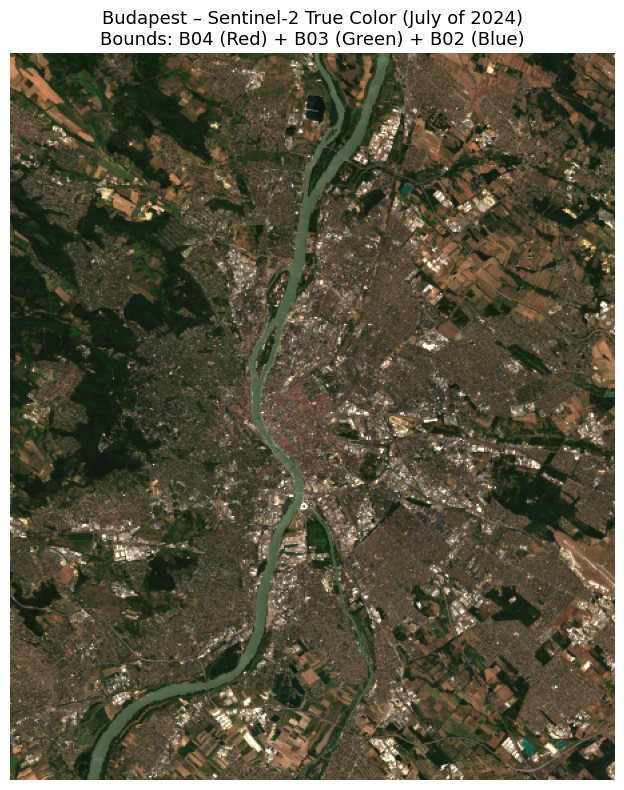

Image saved: budapest_true_color.png


In [37]:
# 3. Plot the image

fig, ax = plt.subplots(figsize=(10, 8))

# PNG 0-255 range to 0-1 range conversion
image_plot = np.clip(image / 255.0, 0, 1)

ax.imshow(image_plot)
ax.set_title(
    "Budapest – Sentinel-2 True Color (July of 2024)\n"
    "Bounds: B04 (Red) + B03 (Green) + B02 (Blue)",
    fontsize=13
)
ax.axis("off")

plt.tight_layout()
plt.savefig("budapest_true_color.png", dpi=150, bbox_inches="tight")
plt.show()
print("Image saved: budapest_true_color.png")